In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/Desktop/Waterloo/Masters/LOO_PIT_Manual/Capse_Planck`


In [2]:
# Pkg.add("Random")
# Pkg.add("LinearAlgebra")
# Pkg.add("Turing")
# Pkg.add("PosteriorStats")
# Pkg.add("Distributions")
# Pkg.add("PDMats")
# Pkg.add("LogExpFunctions")
# Pkg.add("Plots")

In [3]:
using Random
using LinearAlgebra
using Turing
using PosteriorStats
using Distributions
using PDMats
using LogExpFunctions
using Plots

In [4]:
# Define the Turing model
@model function myfoo(SL, x)
    a ~ Uniform(-10, 10)
    b ~ Uniform(-10, 10)
    μ = a .* x .+ b
    S = Symmetric(SL * SL')
    # Multivariate Normal observation
    y ~ MvNormal(μ, PDMat(Cholesky(SL)))
    return y
end

# Setup synthetic data
Random.seed!(1234)
n = 30
R = rand(LKJCholesky(n, 1))
s = rand(filldist(truncated(TDist(7); lower=0), n))
SL = LowerTriangular(Diagonal(s) * R.L) + 0.2I
S = Symmetric(SL * SL')

x = Array(LinRange(-7, 7, n))
a_true = 1.0
b_true = -3.0
y = rand(MvNormal(a_true .* x .+ b_true, S))

30-element Vector{Float64}:
  -9.811564924143633
 -10.859840383966228
  -9.091690033414517
  -8.570246921218109
 -10.586146979442375
  -5.128049478783716
  -7.196124048463768
  -6.974107919160579
  -6.073239474725736
  -5.920146893325242
  -4.3899527348900005
  -4.781161200590691
  -2.3293350537935207
   ⋮
   0.5989245684782158
  -0.2821605760613628
  -1.2792819817595082
   2.1628259832751353
   1.1221721985676112
   1.5957980129853748
   2.0078461434577406
   2.8730649182169663
   6.314391068164985
   3.298919808147355
   5.243683187706106
   3.90450160041801

In [5]:
# Sample from the model using 8 parallel chains
chns = sample(myfoo(SL, x) | (; y), NUTS(), MCMCThreads(), 2000, 8)

# Generate posterior predictions: stochastic realizations from the likelihood
y_pred = predict(myfoo(SL, x), chns)

┌ Info: Found initial step size
└   ϵ = 0.00625
┌ Info: Found initial step size
└   ϵ = 0.00625
┌ Info: Found initial step size
└   ϵ = 0.003125
┌ Info: Found initial step size
└   ϵ = 0.00625
Sampling (4 threads):  14%|███▉                         |  ETA: 0:00:01┌ Info: Found initial step size
└   ϵ = 0.00625
┌ Info: Found initial step size
└   ϵ = 0.00625
Sampling (4 threads):  48%|█████████████▉               |  ETA: 0:00:03┌ Info: Found initial step size
└   ϵ = 0.00625
┌ Info: Found initial step size
└   ϵ = 0.0125
Sampling (4 threads): 100%|█████████████████████████████| Time: 0:00:02


Chains MCMC chain (2000×30×8 Array{Float64, 3}):

Iterations        = 1:1:2000
Number of chains  = 8
Samples per chain = 2000
parameters        = y[1], y[2], y[3], y[4], y[5], y[6], y[7], y[8], y[9], y[10], y[11], y[12], y[13], y[14], y[15], y[16], y[17], y[18], y[19], y[20], y[21], y[22], y[23], y[24], y[25], y[26], y[27], y[28], y[29], y[30]
internals         = 

Summary Statistics
  parameters       mean       std      mcse     ess_bulk     ess_tail      rha ⋯
      Symbol    Float64   Float64   Float64      Float64      Float64   Float6 ⋯

        y[1]   -10.1154    1.0680    0.0084   16052.1143   15619.2564    1.000 ⋯
        y[2]    -9.6302    0.9799    0.0079   15316.4400   15281.4769    1.000 ⋯
        y[3]    -9.1219    3.2593    0.0257   16042.2965   15360.2082    1.000 ⋯
        y[4]    -8.6605    1.8395    0.0144   16221.2487   15340.1434    0.999 ⋯
        y[5]    -8.1408    1.1395    0.0091   15751.9522   15859.8987    1.000 ⋯
        y[6]    -7.6571    1.1184    0.0088  

In [6]:
# Extract parameter samples
a_samples = chns[:a].data
b_samples = chns[:b].data

# Compute the mean array for all draws and chains (draws, chains, n)
μ_array = a_samples .* reshape(x, 1, 1, n) .+ b_samples
S_pd = PDMat(Cholesky(SL))

# Instantiate distributions for each posterior slice
dists = map(μ -> MvNormal(μ, S_pd), eachslice(μ_array; dims=(1, 2)))

# Calculate pointwise conditional log-likelihoods
log_like = PosteriorStats.pointwise_conditional_loglikelihoods(y, dists)

2000×8×30 Array{Float64, 3}:
[:, :, 1] =
 -0.892823  -0.375793  -1.50165   …  -0.812887  -1.84338    -0.109619
 -2.18487   -0.392198  -1.09913      -2.00517   -0.336721   -2.06813
 -2.73159   -0.616539  -2.03185      -1.05128   -1.89675    -0.216221
 -1.81355   -0.586787  -2.73763      -1.05128   -1.7057     -0.961709
 -2.60961   -0.649942  -0.800654     -0.389567  -0.0238539  -1.01569
 -0.650271  -0.762879  -0.800654  …  -0.389567  -1.64238    -0.521548
 -1.48196   -0.611852  -0.786145     -1.23944   -0.441323   -0.430765
 -1.01602   -1.34901   -1.4348       -1.13091   -2.45273    -0.903171
 -0.655844  -1.35346   -1.57393      -1.60943   -3.77489    -0.839258
 -0.683102  -1.00947   -0.374642     -1.57516   -4.58411    -0.407184
 -0.288229  -0.648893  -1.02057   …  -1.15573   -1.63317    -0.554463
 -0.434668  -0.450736  -0.633819     -1.88132   -1.29261    -1.03574
 -0.434668  -0.931471  -0.392679     -0.717991  -1.8849     -0.914908
  ⋮                               ⋱   ⋮             

In [7]:
# Compute LOO to obtain smoothed importance weights
loo_res = loo(log_like)
log_weights = loo_res.psis_result.log_weights

2000×8×30 Array{Float64, 3}:
[:, :, 1] =
 -10.2771   -10.7941    -9.66824  …  -10.357     -9.32651  -11.0603
  -8.98502  -10.7777   -10.0708       -9.16472  -10.8332    -9.10175
  -8.43829  -10.5533    -9.13803     -10.1186    -9.27313  -10.9537
  -9.35634  -10.5831    -8.43226     -10.1186    -9.46419  -10.2082
  -8.56028  -10.5199   -10.3692      -10.7803   -11.146    -10.1542
 -10.5196   -10.407    -10.3692   …  -10.7803    -9.5275   -10.6483
  -9.68793  -10.558    -10.3837       -9.93044  -10.7286   -10.7391
 -10.1539    -9.82087   -9.73508     -10.039     -8.71716  -10.2667
 -10.514     -9.81642   -9.59596      -9.56046   -7.4304   -10.3306
 -10.4868   -10.1604   -10.7952       -9.59473   -6.56296  -10.7627
 -10.8817   -10.521    -10.1493   …  -10.0142    -9.53671  -10.6154
 -10.7352   -10.7191   -10.5361       -9.28856   -9.87727  -10.1341
 -10.7352   -10.2384   -10.7772      -10.4519    -9.28499  -10.255
   ⋮                              ⋱    ⋮                   
 -10.7865    -9

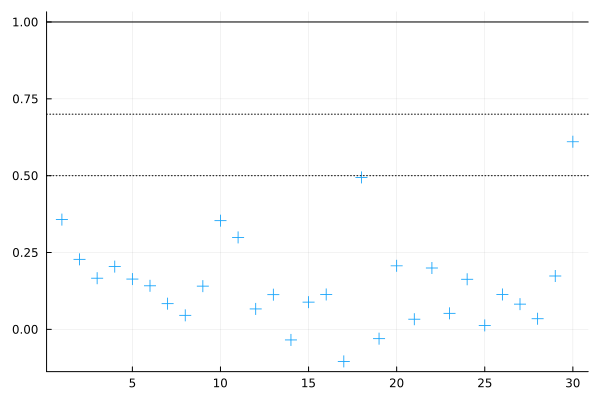

In [8]:
scatter(loo_res.pointwise.pareto_shape; marker=:+, markersize = 6, legend=false, linewidth=2)
hline!([0.5, 0.7], linestyle=:dot, color=:black)
hline!([1.0], linestyle=:solid, color=:black)

In [9]:
# Clean predictions into (draws, chains, n)
y_pred_array = permutedims(y_pred[[Symbol("y[$i]") for i in 1:n]].value.data, (1, 3, 2))

pitvals_manual = zeros(n)
for i in 1:n
    y_pred_i = y_pred_array[:, :, i] 
    log_w_i = log_weights[:, :, i]
    
    # Identify which draws fall below the observation
    mask = y_pred_i .<= y[i]
    
    # Estimate the CDF as the sum of the weights of those draws
    pitvals_manual[i] = any(mask) ? exp(logsumexp(log_w_i[mask])) : 0.0
end

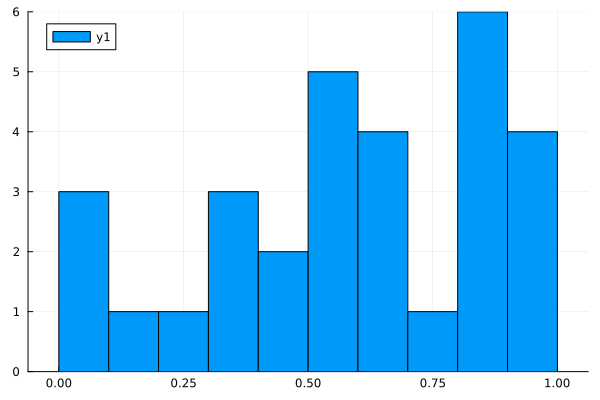

In [10]:
histogram(pitvals_manual, bins=10)

In [11]:
kde_bw = 0.15 # Tuned bandwidth for smoothness on N=30 samples

p = plot(title="LOO-PIT KDE vs uniform reference",
         xlabel="LOO-PIT value", ylabel="Density",
         xlims=(0, 1), ylims=(0, 2.5),
         legend=:topright)

# Helper function to compute bounded KDE over[2]
function get_bounded_kde(data, bw)
    k = PosteriorStats.kde_reflected(data, bounds=(0, 1), bandwidth=bw)
    # Only keep points inside[2]
    mask = 0.0 .<= k.x .<= 1.0
    return k.x[mask], k.density[mask]
end

# Plot 100 uniform reference KDEs in the background
for i in 1:100
    ref_sample = rand(Uniform(0, 1), nobs)
    rx, ry = get_bounded_kde(ref_sample, kde_bw)
    plot!(p, rx, ry, color=:lightblue, alpha=0.3, linewidth=1, 
          label=i==1 ? "Uniform reference" : "")
end

# Plot actual LOO-PIT KDE in the foreground
ox, oy = get_bounded_kde(pitvals_manual, kde_bw)
plot!(p, ox, oy, color=:darkblue, linewidth=3, label="Observed LOO-PIT")

LoadError: UndefVarError: `nobs` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
Hint: a global variable of this name may be made accessible by importing StatsAPI in the current active module Main
Hint: a global variable of this name may be made accessible by importing StatsBase in the current active module Main